# 07 · The Central Limit Theorem and the Standard Error

**Session 9 · Sat Oct 3 · 1.5 hours (stats half)**

> **The centerpiece of the whole five weeks.** Everything in Sessions 10–12 — p-values, confidence
> intervals, t-tests, the bootstrap — is a consequence of what you are about to watch happen.

### The problem statistics exists to solve

You have one sample. You want to know about the population. You will never see the population.

So: **how wrong is my sample likely to be?** If you can answer that, you can attach an honest margin
of error to any estimate. If you cannot, every number you report is naked.

The answer comes from an idea that sounds absurd until you see it: *the average of a sample is itself
a random quantity with its own, highly predictable, distribution.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

## 1 · Build a population that is nothing like a bell curve

To show that this works in general, we deliberately start with a horrible distribution: heavily
right-skewed, like account balances.

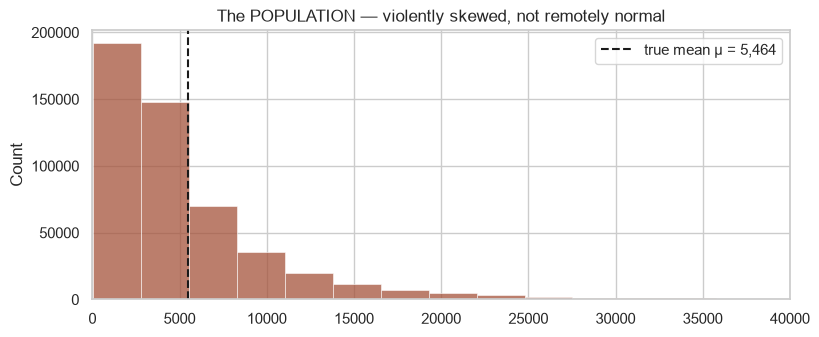

population mean   µ =     5,464.38
population std    σ =     6,186.09
population skew     =         5.54   <- very far from symmetric


In [2]:
population = rng.lognormal(mean=8.2, sigma=0.9, size=500_000)
TRUE_MEAN = population.mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(population, bins=120, ax=ax, color="#a5533b")
ax.axvline(TRUE_MEAN, color="k", ls="--", label=f"true mean µ = {TRUE_MEAN:,.0f}")
ax.set_xlim(0, 40_000)
ax.set_title("The POPULATION — violently skewed, not remotely normal")
ax.legend(); plt.show()

print(f"population mean   µ = {TRUE_MEAN:>12,.2f}")
print(f"population std    σ = {population.std():>12,.2f}")
print(f"population skew     = {pd.Series(population).skew():>12,.2f}   <- very far from symmetric")

## 2 · Take one sample, like a real analyst

In real life you get **one** sample of maybe 100 accounts, and you must report something.

In [3]:
one_sample = rng.choice(population, size=100, replace=False)
print(f"your sample mean x̄ = {one_sample.mean():>12,.2f}")
print(f"the true mean    µ = {TRUE_MEAN:>12,.2f}")
print(f"you were off by    {one_sample.mean() - TRUE_MEAN:>+12,.2f}"
      f"  ({(one_sample.mean()/TRUE_MEAN - 1):+.2%})")

your sample mean x̄ =     5,073.01
the true mean    µ =     5,464.38
you were off by         -391.36  (-7.16%)


You were off. Of course you were. **The question is not "was I wrong" — you always are. The question
is "by how much, typically?"**

Nobody can answer that from one sample by looking at it. But we have the population here, so we can
cheat and find out what *would* happen across many samples. That is the trick of this notebook: do
the impossible experiment once, learn the rule, then use the rule when you cannot cheat.

## 3 · The impossible experiment: 5,000 analysts

Imagine 5,000 analysts each independently drawing their own sample of 100 accounts and each computing
their own mean. What does the collection of their answers look like?

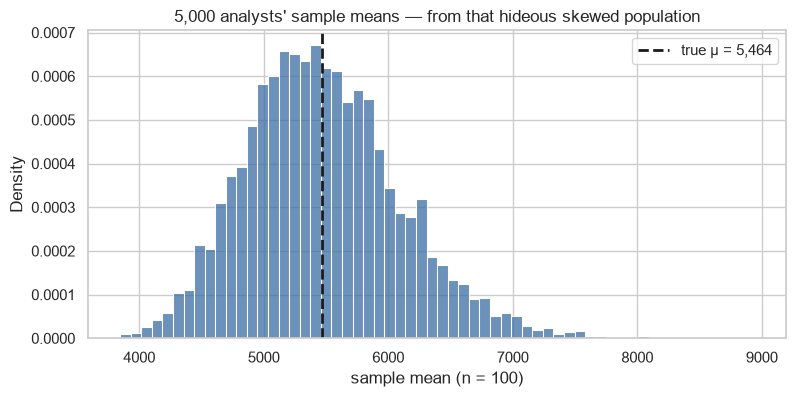

mean of the 5,000 means:     5,474.19   (true µ = 5,464.38)
skew of the 5,000 means:         0.51   (population skew was 3+)


In [4]:
def sampling_distribution(pop, n, reps=5000):
    """Draw `reps` samples of size n; return their means."""
    return np.array([rng.choice(pop, size=n, replace=False).mean() for _ in range(reps)])

means_100 = sampling_distribution(population, 100)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(means_100, bins=60, ax=ax, color="#3b6ea5", stat="density")
ax.axvline(TRUE_MEAN, color="k", ls="--", lw=2, label=f"true µ = {TRUE_MEAN:,.0f}")
ax.set_title("5,000 analysts' sample means — from that hideous skewed population")
ax.set_xlabel("sample mean (n = 100)")
ax.legend(); plt.show()

print(f"mean of the 5,000 means: {means_100.mean():>12,.2f}   (true µ = {TRUE_MEAN:,.2f})")
print(f"skew of the 5,000 means: {pd.Series(means_100).skew():>12,.2f}   (population skew was 3+)")

## 4 · That is the Central Limit Theorem

Look at what just happened:

- The population was **wildly skewed.**
- The distribution of sample *means* is **almost perfectly symmetric and bell-shaped.**
- It is **centered on the true mean.**

**The Central Limit Theorem:** for a large enough sample, the distribution of the sample mean is
approximately normal — *regardless of the shape of the population it came from.*

This is the most useful theorem in applied statistics, and the reason is practical: you almost never
know the shape of your population, and the CLT says **you do not need to.** Whatever it looks like,
your sample mean behaves normally, and normal distributions are something we can compute with.

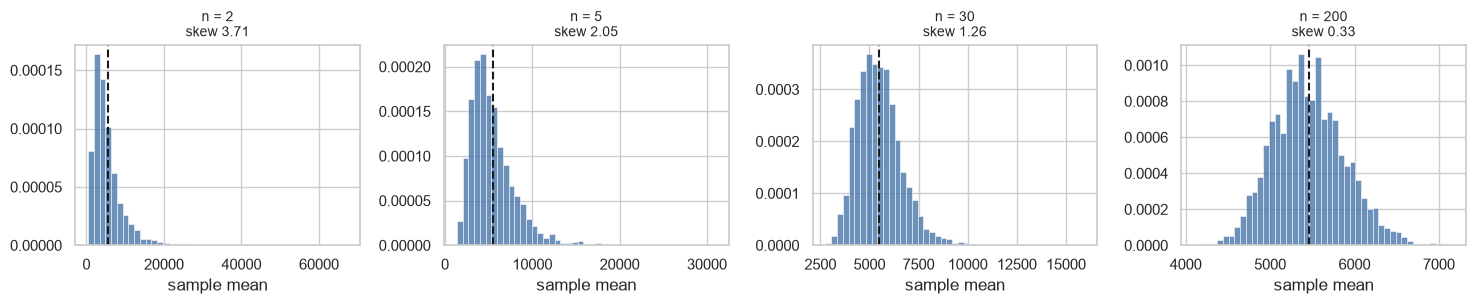

n=2 still inherits the population's skew. By n=30 it is nearly gone. This is where
the folk rule 'n ≥ 30' comes from -- though heavier skew needs more.


In [5]:
# Watch normality arrive as n grows.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for axis, n in zip(axes, [2, 5, 30, 200]):
    m = sampling_distribution(population, n, reps=3000)
    sns.histplot(m, bins=45, ax=axis, color="#3b6ea5", stat="density")
    axis.axvline(TRUE_MEAN, color="k", ls="--")
    axis.set_title(f"n = {n}\nskew {pd.Series(m).skew():.2f}", fontsize=10)
    axis.set_ylabel(""); axis.set_xlabel("sample mean")
plt.tight_layout(); plt.show()
print("n=2 still inherits the population's skew. By n=30 it is nearly gone. This is where")
print("the folk rule 'n ≥ 30' comes from -- though heavier skew needs more.")

## 5 · The standard error — and the distinction that trips everyone

The spread of that bell is the **standard error**. It measures how much sample means vary.

$$SE = \frac{\sigma}{\sqrt{n}}$$

In [6]:
sigma = population.std()
for n in (10, 30, 100, 400, 1600):
    m = sampling_distribution(population, n, reps=2500)
    print(f"n={n:>5}   observed spread of means = {m.std():>9,.1f}   "
          f"σ/√n = {sigma/np.sqrt(n):>9,.1f}")

n=   10   observed spread of means =   1,932.9   σ/√n =   1,956.2
n=   30   observed spread of means =   1,119.2   σ/√n =   1,129.4
n=  100   observed spread of means =     614.9   σ/√n =     618.6
n=  400   observed spread of means =     309.1   σ/√n =     309.3
n= 1600   observed spread of means =     153.5   σ/√n =     154.7


### σ versus SE — read this twice

| | What it describes | Does more data shrink it? |
|---|---|---|
| **σ** (standard deviation) | how much **individual accounts** differ | **No.** Never. |
| **SE** (standard error) | how much **your estimate of the mean** would differ | **Yes**, like `1/√n`. |

Collecting more data does not make customers more alike. The world is exactly as variable as it was.
What more data buys you is a **more reliable estimate** — the bell in section 3 gets narrower.

Confusing these two is the most common error in applied statistics, and it shows up as reports
claiming the *population* got more homogeneous when in fact only the *estimate* got sharper.

### Diminishing returns

`√n` is a harsh master. To halve your standard error you must **quadruple** your sample.

In [7]:
base = sigma / np.sqrt(100)
print(f"n =   100  ->  SE = {base:>9,.1f}")
for n in (400, 1600, 6400):
    print(f"n = {n:>5}  ->  SE = {sigma/np.sqrt(n):>9,.1f}   "
          f"({base/(sigma/np.sqrt(n)):.0f}x better, {n//100}x the data)")
print("\n64x the data for an 8x improvement. This is why 'just collect more data'")
print("stops being good advice quite early, and why study DESIGN matters more than volume.")

n =   100  ->  SE =     618.6
n =   400  ->  SE =     309.3   (2x better, 4x the data)
n =  1600  ->  SE =     154.7   (4x better, 16x the data)
n =  6400  ->  SE =      77.3   (8x better, 64x the data)

64x the data for an 8x improvement. This is why 'just collect more data'
stops being good advice quite early, and why study DESIGN matters more than volume.


## 6 · Where the "95%" in everything comes from

Since sample means are normal, the 68/95/99.7 rule applies **to them**. About 95% of sample means
land within 2 standard errors of the truth (1.96, precisely).

Turn that around and you get the confidence interval: `x̄ ± 1.96 × SE`.

In [8]:
n = 100
within = np.mean(np.abs(means_100 - TRUE_MEAN) < 1.96 * sigma/np.sqrt(n))
print(f"share of the 5,000 sample means within 1.96·SE of µ: {within:.1%}")
print()

# Now build an interval the honest way -- from ONE sample, not knowing sigma.
covered = 0
trials = 2000
for _ in range(trials):
    s = rng.choice(population, size=n, replace=False)
    se = s.std(ddof=1) / np.sqrt(n)              # estimate SE from the sample itself
    lo, hi = s.mean() - 1.96*se, s.mean() + 1.96*se
    covered += (lo <= TRUE_MEAN <= hi)

print(f"of {trials} intervals built from single samples, {covered/trials:.1%} contained the true µ")
print("\nTHAT is what '95% confidence' means: the PROCEDURE captures the truth 95% of")
print("the time. It is a property of the method across repetitions -- not a probability")
print("statement about any one interval you happen to have computed.")

share of the 5,000 sample means within 1.96·SE of µ: 95.1%

of 2000 intervals built from single samples, 93.2% contained the true µ

THAT is what '95% confidence' means: the PROCEDURE captures the truth 95% of
the time. It is a property of the method across repetitions -- not a probability
statement about any one interval you happen to have computed.


## Your turn

**Exercise 1.** Using the `lending` data as a population, draw 2,000 samples of 50 loans and plot the
distribution of their mean `annual_income`. Compare the observed spread to `σ/√n`.

In [9]:
# your code here

In [ ]:
lending = pd.read_csv(DATA / "lending.csv")
inc = lending.annual_income.values

means = np.array([rng.choice(inc, 50, replace=False).mean() for _ in range(2000)])

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(means, bins=45, ax=ax)
ax.axvline(inc.mean(), color="k", ls="--", label=f"true mean {inc.mean():,.0f}")
ax.legend(); plt.show()

print(f"observed spread of means: {means.std():>10,.1f}")
print(f"σ/√n predicted:           {inc.std()/np.sqrt(50):>10,.1f}")

**Exercise 2.** You need a standard error of $500 for mean income. Roughly what sample size does that
require? (Use `σ` from the full lending data and solve `σ/√n = 500`.)

In [11]:
# your code here

In [ ]:
sigma_inc = lending.annual_income.std()
n_needed = (sigma_inc / 500) ** 2
print(f"σ = {sigma_inc:,.0f}")
print(f"n = (σ/500)² = {n_needed:,.0f}")

s = rng.choice(lending.annual_income.values, int(n_needed), replace=False)
print(f"check: SE at that n = {s.std(ddof=1)/np.sqrt(len(s)):,.1f}")
# Note this is a DESIGN calculation -- done before collecting data, to decide how much
# to collect. It is the single most practical use of the SE formula.

**Exercise 3.** The CLT is about the *mean*. Does the same thing happen to the sample **maximum**?
Draw 3,000 samples of 100 and plot the distribution of their maxima.

In [13]:
# your code here

In [ ]:
maxima = np.array([rng.choice(population, 100, replace=False).max() for _ in range(3000)])

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(maxima, bins=60, ax=ax, color="#a5533b")
ax.set_title("Distribution of sample MAXIMA — still strongly skewed")
plt.show()
print(f"skew of sample maxima: {pd.Series(maxima).skew():.2f}   (means had skew ≈ 0)")

# NOT normal. The CLT applies to sums and averages, not to extremes. Maxima follow
# their own theory (extreme value theory), which is why tail-risk and stress-testing
# work cannot borrow ordinary confidence intervals. Worth knowing where a theorem stops.

## What you did today

- Watched the **Central Limit Theorem** happen: sample means go normal even from a violently skewed population.
- Learned `SE = σ/√n`, and that halving it costs 4× the data.
- Nailed the **σ vs SE** distinction — spread of individuals vs reliability of an estimate.
- Saw that "95% confidence" is a property of the **procedure across repetitions**, not of your one interval.
- Found where the CLT *stops* applying (extremes), which is as useful as knowing where it does.

**Next:** `08_hypothesis_testing.ipynb` — all of which is just this notebook with different vocabulary.